# AI ANALYST LAB

![](../_img/Ghost_TheSyntheticBanner.png)

### A Hands-on Course on AI for Data Analysts
## Session 07: Visualizing and communicating clusters with t-SNE

Feedback should be sent to [goran.milovanovic@datakolektiv.com](mailto:goran.milovanovic@datakolektiv.com).

This notebook accompanies the **AI Analyst LAB** course. Welcome to Session 07 — the week we take the segments we *found* last week and learn to **show** them: to turn six columns of numbers into a single picture you can put in front of a busy executive and have them understand it in ten seconds.


***
### What we will do today

Let us take a moment to see how far you have come. In **Session 01** you learned descriptive statistics, three probability distributions, and the sampling distribution of the mean. **Session 02** added conditional probability, expected value, and the bootstrap. **Session 03** built the hypothesis-testing framework. **Session 04** crossed into relationships between numbers — covariance, correlation, and **linear regression**. **Session 05** fit a **logistic regression** to predict a yes/no outcome. And last week, in **Session 06**, you did something different in kind: with **no answer column to learn from**, you used **k-means clustering** to *discover* three customer segments hiding in the spending data, and you named them from the evidence:

- **Grocery & Household-Goods Retailers** — about 80 customers,
- **High-Volume All-Rounders** — about 147 customers,
- **Fresh-Focused Food Service** — about 213 customers.

That was real, useful work. But it has a presentation problem, and this week is entirely about solving it.

**The problem.** Each customer lives in a space with **six axes** — one for each product category (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`). We humans can comfortably read a picture with **two** axes, maybe three. Nobody can *see* six dimensions. So when the VP of Sales asks *"show me these segments"*, you cannot just draw them — there is no six-dimensional whiteboard.

**The fix.** This week you learn **dimension reduction**: a family of techniques that squeeze many dimensions down to two, so the whole customer base becomes a single scatter plot — one dot per customer — where similar customers sit close together. We will meet two such techniques: the classic **PCA**, and this week's star, **t-SNE**, which is purpose-built for making clusters *visible*.

The deliverable is different from last week too. Session 06 produced a *segmentation*. This week produces a **Cluster Story Pack**: one clear picture, a plain-English narrative of who the segments are and what to do about them, an honest box of caveats, and an AI-drafted slide-deck outline — everything you need to walk into a meeting and *land* the segmentation.

The business setting is the same **wholesale food-and-goods distributor** as last week. The sections, in order:

| Section | What happens |
|---|---|
| 7.1 | The business case — sell the segmentation to non-technical stakeholders |
| 7.2 | Meet your Session 07 Tutor (Claude Project) |
| 7.3 | Setup — imports, and rebuilding last week's segmentation |
| 7.4 | **The problem** — why we cannot just plot six dimensions |
| 7.5 | **Dimension reduction** — making a faithful two-dimensional shadow |
| 7.6 | **PCA** — the classic, linear warm-up (and a little history) |
| 7.7 | **t-SNE** — the idea, in plain language |
| 7.8 | **Running t-SNE** — the picture for the meeting |
| 7.9 | **Does the picture agree?** — an external-validation check with `Channel` |
| 7.10 | **Reading t-SNE responsibly** — three honest caveats |
| 7.11 | **PCA vs t-SNE** — two tools, two jobs (and their cousins) |
| 7.12 | **The Cluster Story Pack** — assembling the deliverable |
| 7.13 | Our API calls — Anthropic drafts the slide deck |
| 7.14 | The cluster story pack — fully worked |
| 7.15 | References — what to study to deepen this session |
| 7.16 | Recap, and a look ahead to Session 08 |

A few rules for using this notebook, same as the previous six weeks:

- **Run the cells in order.** Each section builds on the one before.
- **Read the explanations, do not just run the cells.** The intuition is the point.
- **Every line of code has a comment above it** in beginner language.
- **Use your Session 07 Tutor** (the Claude Project at `_tutors/session07_tutor.xml`) when something feels confusing.
- **Compute first in Python, then use the model to interpret.** Same rule as Sessions 01–06 — the model never invents numbers.


***
## 7.1 The business case

It is the week after you delivered the segmentation. The Head of Commercial was pleased — and promptly booked you into something bigger:

> *"Next Tuesday I want you in the room with the **VP of Sales** and the regional managers. I need you to **sell** this segmentation to them in fifteen minutes. No jargon, no statistics lecture — they will switch off. Give them one picture they can actually look at, tell them who each segment is, tell them what we do differently for each, and be honest about what the analysis can and cannot promise. If they believe it, we re-organise the sales playbooks around it. If they do not, it dies in that room."*

Read that brief carefully, because it changes the job. Last week the question was *"what are the segments?"* — a question about the **data**. This week the question is *"how do I make people believe and use the segments?"* — a question about **communication**. The statistics are done; now you are a translator.

Two things stand between you and a convincing fifteen minutes:

1. **You cannot show six dimensions.** Your evidence lives across six spending categories. A table of six numbers per segment is accurate but deadening; people cannot *see* groups in a table.
2. **You must be honest without being scary.** The picture you will use (t-SNE) is genuinely persuasive, but it is easy to *over*-read. A responsible analyst shows the picture *and* tells the room exactly which parts of it to trust.

Your final deliverable this Friday — the thing the rest of this notebook builds toward — is a **Cluster Story Pack**:

1. **One picture** — a single 2D map of all 440 customers, coloured by segment, that a non-technical person understands at a glance.
2. **A stakeholder narrative** — who each segment is, and the one "so what" action per segment.
3. **An honesty box** — the two or three caveats the room must hear.
4. **A slide-deck outline** — drafted by Anthropic from the numbers you compute, ready to drop into slides.

Everything below serves that pack.


***
## 7.2 Meet your Session 07 Tutor

As in every session, you have a **Claude Project** acting as your personal statistics tutor for this week's ideas. The prompt lives in the repository at `_tutors/session07_tutor.xml`, and the setup walkthrough is in `_tutors/TutorProjectCreation.md`.

Your **Session 07 Tutor** is scoped to *this* session only — dimension reduction, what PCA and t-SNE each do, the meaning of perplexity, and above all how to read a t-SNE picture *responsibly*. It will not race ahead to topics we have not covered. Use it whenever a sentence here does not click: paste the sentence in and ask *"explain this more slowly, with a tiny example."*

Three reminders about the wider tutor system:

- For questions about **Python, pandas, NumPy, matplotlib, or seaborn** — *"what does `fit_transform` return?"* — use the cross-session **Python Stack Tutor** (`_tutors/python_stack_tutor.xml`).
- For questions about **earlier statistics** — the z-score from Session 01, the k-means machinery from Session 06 — those sessions' own tutors are the right place.
- Later in this notebook (§7.13) you will build a **Stakeholder Translator Assistant** of your own — a Claude prompt whose whole job is to turn segment statistics into plain-English narrative. That is a *prompt-engineering exercise*, separate from this learning tutor.

The discipline we have kept since Session 01 holds again: **Python computes the numbers; the model only helps you interpret and communicate them.** The model never invents a number.


***
## 7.3 Setup — imports, and rebuilding last week's segmentation

We start by loading the tools. Most are old friends. Two are new this week, and both come from **scikit-learn** (imported as `sklearn`):

- **`PCA`** — *Principal Component Analysis*, the classic linear dimension-reduction method (§7.6).
- **`TSNE`** — *t-distributed Stochastic Neighbor Embedding*, this week's star (§7.7 onward).

We also bring back **`StandardScaler`** and **`KMeans`** from Session 06, because the very first thing we must do is **rebuild the exact segmentation from last week** — this notebook should stand on its own. And we import **`NearestNeighbors`**, which we will use for one small, honest quality check on our map.

Run the cell below. It imports everything and prints each library's version, so that if a number here ever differs from a number on your screen, you can check whether a version mismatch is the reason.


In [1]:
# pandas gives us the DataFrame — the table-with-labels we have used since Session 01.
import pandas as pd

# numpy gives us fast array maths (logs, sums over columns).
import numpy as np

# matplotlib is our base plotting library.
import matplotlib.pyplot as plt

# seaborn sits on top of matplotlib and makes good-looking statistical plots with less code.
import seaborn as sns

# StandardScaler rescales each column to mean 0 and standard deviation 1 (the z-score, from Session 01).
from sklearn.preprocessing import StandardScaler

# KMeans is the clustering algorithm we used last week, in Session 06.
from sklearn.cluster import KMeans

# PCA is our first dimension-reduction tool — the classic, linear one (§7.6).
from sklearn.decomposition import PCA

# TSNE is this week's star — a non-linear map built for visualising clusters (§7.7 onward).
from sklearn.manifold import TSNE

# NearestNeighbors lets us check, for each customer, how many of its nearest neighbours on the map share its segment.
from sklearn.neighbors import NearestNeighbors

# Tell Jupyter to draw plots directly under each cell.
%matplotlib inline

# Apply a clean, consistent visual theme to every plot in the notebook.
sns.set_theme(style="whitegrid")

# Import the top-level sklearn package just so we can print its version below.
import sklearn

# Print the version of each library, so any number mismatch can be traced to a version difference.
print("pandas:      ", pd.__version__)
print("numpy:       ", np.__version__)
print("matplotlib:  ", plt.matplotlib.__version__)
print("seaborn:     ", sns.__version__)
print("scikit-learn:", sklearn.__version__)

pandas:       3.0.2
numpy:        2.4.4
matplotlib:   3.10.9
seaborn:      0.13.2
scikit-learn: 1.8.0


Now we **rebuild the Session 06 segmentation from scratch**, so this notebook does not depend on the previous one being open. This is a deliberate callback, so let us name exactly what we are reusing:

- **The pipeline from Session 06, §6.7.** The six spending columns were heavily right-skewed, so we first apply `np.log1p` (the natural log of one-plus-the-value) to pull the giant values back toward the pack, and then `StandardScaler` to put every column on the **z-score** scale (mean 0, standard deviation 1 — the same z-score you first met in Session 01, §1.10). Distance-based methods need this, and *t-SNE is distance-based too*, so the same scaling matters again this week.
- **The model from Session 06, §6.12.** We fit `KMeans` with `n_clusters=3`, `random_state=42`, and `n_init=10` — identical settings — so we recover the **same** three segments, with the same sizes.
- **The names from Session 06, §6.15.** We re-attach the evidence-based names we read off the spending profiles.

The cluster numbers `0, 1, 2` are arbitrary tags; the *names* are what matter.


In [2]:
# Build the path to the dataset: one folder up (..), then into _data/wholesale_customers/.
data_path = "../_data/wholesale_customers/Wholesale customers data.csv"

# Read the CSV into a DataFrame called `wholesale`.
wholesale = pd.read_csv(data_path)

# The six spending columns — the ONLY columns we cluster on (Channel and Region are held back).
spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

# Session 06 pipeline, step 1: log1p tames the heavy right-skew (natural log of one-plus-the-value).
wholesale_log = np.log1p(wholesale[spend_cols])

# Session 06 pipeline, step 2: standardise each logged column to mean 0 and standard deviation 1 (the z-score).
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(wholesale_log), columns=spend_cols)

# Session 06 model: re-fit the same k = 3 KMeans (same random_state and n_init -> same segments).
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Attach each customer's cluster label (0, 1, or 2) to the table.
wholesale["cluster"] = kmeans.fit_predict(X_scaled)

# The evidence-based names we read off the spending profiles in Session 06, §6.15.
segment_names = {0: "Grocery & Household-Goods Retailers",
                 1: "High-Volume All-Rounders",
                 2: "Fresh-Focused Food Service"}

# Add a readable name column, handy for colouring plots by segment.
wholesale["segment"] = wholesale["cluster"].map(segment_names)

# Confirm we rebuilt exactly the Session 06 segmentation: the sizes should be 80, 147, and 213.
print("Segment sizes (should match Session 06: 80, 147, 213):")
print(wholesale["cluster"].value_counts().sort_index())

Segment sizes (should match Session 06: 80, 147, 213):
cluster
0     80
1    147
2    213
Name: count, dtype: int64


The sizes come back **80, 147, and 213** — exactly the segmentation we built last week. We are standing on the same ground; the only new job is to *picture* it.

To keep every plot consistent, we will give each segment a fixed colour throughout the notebook:

- **Grocery & Household-Goods Retailers** — red,
- **High-Volume All-Rounders** — blue,
- **Fresh-Focused Food Service** — green.


***
## 7.4 The problem — why we cannot just plot six dimensions

Here is the temptation: *"If I cannot draw six axes, why not just draw two of them at a time?"* It is a reasonable instinct, so let us try it and watch it fall short.

Each customer is described by six numbers. A scatter plot can show exactly **two** of those numbers — say `Fresh` on one axis and `Grocery` on the other. But the moment we do that, we have **thrown away the other four categories entirely.** Each two-axis plot is like a single photograph of a sculpture from one angle: useful, but it hides everything around the back.

We will draw two such "photographs" below, each colouring the dots by their true segment. If two axes were enough, we would see the three colours fall into three clean, separated clouds. Watch what actually happens.


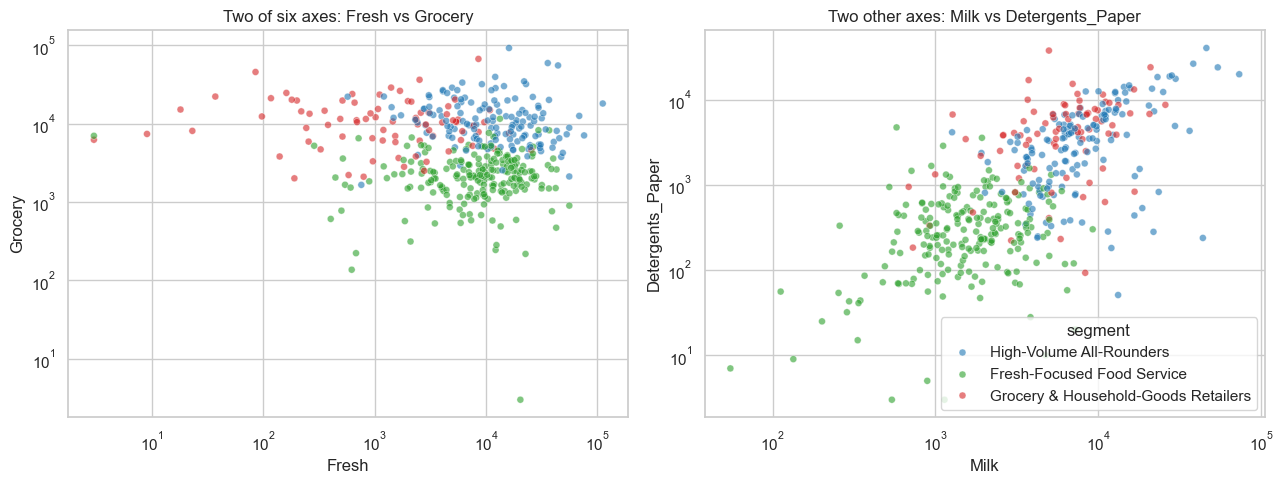

In [3]:
# A fixed colour for each segment, reused in every plot in this notebook.
seg_palette = {"Grocery & Household-Goods Retailers": "#d62728",  # red
               "High-Volume All-Rounders":            "#1f77b4",  # blue
               "Fresh-Focused Food Service":          "#2ca02c"}  # green

# Two side-by-side scatter plots, each showing just two of the six spending columns.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: Fresh against Grocery, with dots coloured by segment.
sns.scatterplot(data=wholesale, x="Fresh", y="Grocery", hue="segment",
                palette=seg_palette, alpha=0.6, s=25, ax=axes[0], legend=False)
# Use log scales so the few giant spenders do not squash everyone into one corner.
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Two of six axes: Fresh vs Grocery")

# Right panel: Milk against Detergents_Paper, again coloured by segment.
sns.scatterplot(data=wholesale, x="Milk", y="Detergents_Paper", hue="segment",
                palette=seg_palette, alpha=0.6, s=25, ax=axes[1])
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Two other axes: Milk vs Detergents_Paper")

# Tidy spacing and show the figure.
plt.tight_layout(); plt.show()

**What we see.** There are *hints* of structure — the green Fresh-Focused customers drift toward high `Fresh`, the red Retailers toward high `Grocery` and `Detergents_Paper` — but the three colours **overlap heavily**. No single pair of axes pulls all three groups cleanly apart, because each plot is blind to four of the six categories. And remember: there are **fifteen** different pairs of columns we *could* plot. Asking a VP to hold fifteen scatter plots in their head and mentally combine them is a non-starter.

What we want is a **single** picture that uses **all six** categories at once and lays the customers out so that similar customers are close and different customers are far. That is exactly what dimension reduction does.


***
## 7.5 Dimension reduction — making a faithful shadow

Hold your hand up in front of a lamp and look at the shadow it casts on the wall. Your hand is a three-dimensional object, but the shadow is **two-dimensional** — and yet you can still tell it is a hand, count the fingers, see whether it is open or in a fist. The shadow has **thrown away one dimension (depth)** but **kept the information that matters** for recognising the shape.

**Dimension reduction** is exactly this idea, applied to data and pushed further: it takes points living in many dimensions (our six) and produces a **shadow in two dimensions** that keeps as much of the important structure as possible. The two new numbers it gives each customer are called an **embedding** — just a new pair of coordinates, a position on a flat map. There are no "units" on these new axes; they are a layout, not a measurement.

The interesting part is the phrase *"the information that matters"*, because different methods disagree about what matters, and that choice is the whole story:

- **Keep the big global directions of spread.** Find the few directions along which customers differ the most, and use those as the new axes. This is **PCA** (§7.6). It is *linear* — it can only rotate and flatten the cloud, like choosing the best angle to photograph the sculpture.
- **Keep who-is-near-whom locally.** Forget the global shape; just make sure each customer ends up next to the same neighbours they had in the original six-dimensional space. This is **t-SNE** (§7.7). It is *non-linear* — it can bend and stretch the space to pull groups apart.

Two philosophies, two pictures. We will build both and compare them honestly. We start with the older, simpler one.


***
## 7.6 PCA — the classic, linear warm-up

**Principal Component Analysis (PCA)** is the grandparent of dimension reduction. The idea, in one breath: *find the direction in which the customers are most spread out, call it the first principal component; then find the next direction, at right angles to the first, with the most remaining spread, and call it the second; keep the top two as your map.*

A **principal component** is just a weighted blend of the original columns — for example, *"a bit of `Fresh`, plus a lot of `Grocery`, plus a lot of `Detergents_Paper`, minus a bit of `Frozen`."* PCA chooses the blend that spreads the customers out as much as possible. The amount of the data's total spread that a component captures is its **explained variance ratio**:

$$\text{explained variance ratio} = \frac{\text{spread captured by this component}}{\text{total spread across all six categories}}$$

If the first two components together capture, say, 70% of the spread, then our flat two-dimensional map preserves about 70% of what made the customers differ — a reasonably faithful shadow.

**A little history.** PCA was invented by Karl Pearson in **1901** — the same Pearson behind the correlation coefficient from Session 04. For most of the twentieth century, when an analyst said *"let us reduce the dimensions,"* they almost always meant PCA: it is fast, it is reproducible, and its axes have a clear meaning. Methods like **t-SNE** (2008) and its modern cousin **UMAP** are recent arrivals, designed specifically to make *clusters* pop visually — something PCA, for all its virtues, often does not do well. We will see that difference with our own eyes in a moment.

Let us run PCA on the same scaled six-dimensional data and project every customer down to two coordinates.


PC1 captures 44.1% of the spread; PC2 captures 27.2%.
Together, the 2D PCA map keeps 71.3% of the original six-dimensional spread.


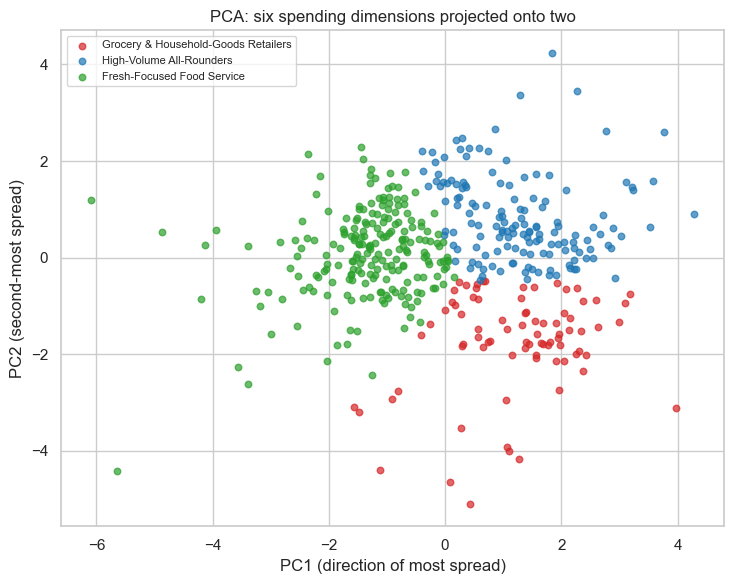

In [4]:
# Create a PCA that keeps the top 2 components (the two directions of greatest spread).
pca = PCA(n_components=2, random_state=42)

# Fit PCA on the scaled features and project every customer down to 2 coordinates.
pca_coords = pca.fit_transform(X_scaled)

# explained_variance_ratio_ holds the share of the data's total spread each component captures.
evr = pca.explained_variance_ratio_

# Report those shares as percentages.
print(f"PC1 captures {evr[0]*100:.1f}% of the spread; PC2 captures {evr[1]*100:.1f}%.")
print(f"Together, the 2D PCA map keeps {evr[:2].sum()*100:.1f}% of the original six-dimensional spread.")

# Draw the PCA scatter: one dot per customer, coloured by segment.
plt.figure(figsize=(7.5, 6))
# Loop over the three segments so each gets its fixed colour and a legend entry.
for name, color in seg_palette.items():
    # A True/False mask selecting the customers in this segment.
    m = (wholesale["segment"] == name).values
    # Plot this segment's customers at their PCA coordinates.
    plt.scatter(pca_coords[m, 0], pca_coords[m, 1], s=22, c=color, label=name, alpha=0.7)
# Label the axes by what they represent.
plt.xlabel("PC1 (direction of most spread)"); plt.ylabel("PC2 (second-most spread)")
plt.title("PCA: six spending dimensions projected onto two")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**What we see.** The first two components together keep about **71%** of the spread (PC1 about 44%, PC2 about 27%) — so this flat map is a fairly faithful shadow of the six-dimensional cloud. And there *is* a recognisable arrangement: the green Fresh-Focused customers gather to the left, the blue All-Rounders to the upper right, the red Retailers to the lower right.

But look how the colours **bleed into one another.** The three segments form a single continuous cloud with a gradient running through it, not three separated islands. That is honest and even informative — it reminds us that customer behaviour really is a *continuum*, and that k-means drew hard lines through it (a point we will keep being honest about). But for *communication*, a smeared cloud is a hard sell: a VP looking at this picture would not immediately "see" three groups.

This is precisely the gap **t-SNE** was built to close.


***
## 7.7 t-SNE — the idea, in plain language

**t-SNE** stands for *t-distributed Stochastic Neighbor Embedding*. The name is intimidating; the idea is not. We will keep this section almost entirely in words and pictures — there is some real mathematics underneath, but you do not need it to *use* t-SNE wisely, and we will deliberately leave the heavy machinery in its box.

Here is the whole idea:

> **t-SNE arranges the dots on a flat map so that each customer ends up next to the same neighbours it had in the original six-dimensional space.**

Think of a big party where people have naturally fallen into conversation clusters across several rooms. t-SNE is like taking a single overhead photo of *one* room into which everyone has been re-seated so that **the people who were already chatting are sitting together**. It does not care whether the marketing group ends up on the left or the right of the photo, or how far the two friend-groups are from each other — it only cares that *each person's immediate neighbours are preserved.*

How does it decide who is a "neighbour"? With the **Euclidean distance** you already met in Session 06, §6.6 — the straight-line distance between two customers across all six categories:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2}$$

where $\mathbf{x}$ and $\mathbf{y}$ are two customers, $p$ is the number of features (here 6), the index $j$ walks through the categories, and $x_j$ and $y_j$ are the two customers' spend on category $j$. Small distance means similar; large distance means different. Because distance is at the heart of t-SNE, the **same scaling lesson from Session 06 applies**: we feed t-SNE the log-and-standardised features, never the raw spend, so that no single big-number category hijacks the notion of "near."

There is exactly **one knob** you need to understand this week: **perplexity**.

- Perplexity is, roughly, *"how many neighbours should each customer pay attention to?"*
- A **small** perplexity (say 5) means each customer looks only at its handful of very nearest neighbours — a very *local* view.
- A **large** perplexity (say 50) means each customer considers a wider circle — a more *global* view.
- Typical values run from about 5 to 50. We will use **30** for our main map, and in §7.10 we will deliberately change it to see how much the picture depends on it.

What about the rest — how t-SNE *scores* a layout and nudges the dots until the 2D neighbourhoods match the 6D ones? That scoring uses ideas from **information theory**, a topic we will open up properly in **Session 08**. For this week, the intuition above is all you need: *t-SNE preserves neighbourhoods, and perplexity sets the size of a neighbourhood.* Let us run it.


***
## 7.8 Running t-SNE — the picture for the meeting

We now fit t-SNE on the **same scaled six-dimensional features** and colour the result by our Session 06 segments. A few arguments to know:

- **`n_components=2`** — we want a two-dimensional map.
- **`perplexity=30`** — a mid-range neighbourhood size (see §7.7).
- **`init="pca"`** — start the layout from the PCA result (§7.6). Starting from a sensible place rather than a random scatter makes the run **stable and repeatable**; we will see in §7.10 why that matters.
- **`learning_rate="auto"`** — let scikit-learn choose a sensible step size.
- **`random_state=42`** — fix the run so you and a colleague get the same picture.

One honest note before we look: the two output axes, "t-SNE 1" and "t-SNE 2", **have no units and no meaning on their own.** They are just a flat canvas. What carries meaning is *which dots end up near which* — the neighbourhoods.


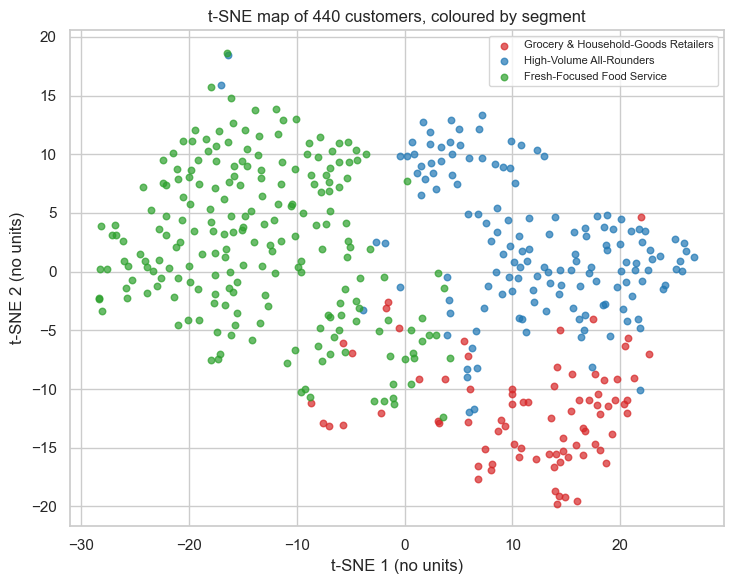

In [5]:
# Create the t-SNE map: 2 output dimensions, perplexity 30 (a mid-range neighbourhood size).
# init="pca" starts from the PCA layout (a stable, repeatable start); learning_rate="auto" picks the step size;
# random_state=42 fixes the run so the picture is reproducible.
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)

# Fit t-SNE on the SAME scaled features and produce two coordinates per customer.
tsne_coords = tsne.fit_transform(X_scaled.values)

# Draw the t-SNE map, coloured by the Session 06 segment.
plt.figure(figsize=(7.5, 6))
# One scatter call per segment, so each gets its fixed colour and a legend entry.
for name, color in seg_palette.items():
    # A True/False mask selecting the customers in this segment.
    m = (wholesale["segment"] == name).values
    # Plot this segment's customers at their t-SNE coordinates.
    plt.scatter(tsne_coords[m, 0], tsne_coords[m, 1], s=22, c=color, label=name, alpha=0.7)
# The axes carry no units — they are just a layout.
plt.xlabel("t-SNE 1 (no units)"); plt.ylabel("t-SNE 2 (no units)")
plt.title("t-SNE map of 440 customers, coloured by segment")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**What we see.** *This* is a picture you can put in a meeting. The three segments occupy three recognisable **territories**: the green Fresh-Focused Food Service customers fill the left, the blue High-Volume All-Rounders gather in the upper right, and the red Grocery & Household-Goods Retailers sit in the lower right. Where last week's six columns were invisible and §7.6's PCA cloud was smeared, t-SNE has pulled the groups apart into something a non-technical person reads in seconds.

Notice also the **soft seams** where territories meet — a few dots sit on the border between two colours. That is not a flaw; it is the truth showing through. Customer behaviour is a continuum, and the customers near a seam are the ones who could reasonably belong to either group. We will say this out loud to stakeholders rather than hide it.

Let us put one honest number on the claim that "similar customers ended up together."


In [6]:
# A small helper: for each customer, what share of its k nearest neighbours on the MAP share its segment?
def neighbourhood_purity(coords, labels, k=10):
    # Find the k+1 nearest points to each point (the +1 is the point itself).
    finder = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    # For each point, get the indices of its nearest points.
    _, neighbours = finder.kneighbors(coords)
    # Drop the first column, because every point is its own closest neighbour.
    neighbours = neighbours[:, 1:]
    # Turn the labels into a plain array for fast comparison.
    lab = np.asarray(labels)
    # For each point, what fraction of its neighbours share its label? Average over all customers.
    return (lab[neighbours] == lab[:, None]).mean()

# Apply it to the t-SNE map, using the segment labels and the 10 nearest neighbours.
purity = neighbourhood_purity(tsne_coords, wholesale["cluster"].values, k=10)

# Report the result as a percentage.
print(f"On this map, {purity*100:.1f}% of each customer's 10 nearest neighbours belong to the same segment.")

On this map, 88.5% of each customer's 10 nearest neighbours belong to the same segment.


**What we see.** About **88%** of each customer's ten nearest neighbours on the map share its segment. In plain words: *the map keeps like with like.* Note carefully what this number does and does not say — it is about **local neighbourhoods** ("who is right next to me?"), which is exactly what t-SNE is built to preserve. It says **nothing** about the *distance between* the coloured territories, which, as we are about to insist, you must not read into. We chose this neighbourhood-based check precisely because it stays inside what t-SNE can honestly promise.


***
## 7.9 Does the picture agree? An external-validation check

In Session 06, §6.15 we ran a beautiful test: we had deliberately **held back** the `Channel` column (1 = Horeca — hotels, restaurants, cafés; 2 = Retail — shops) so the clustering never saw it, and then we checked whether the spending-only segments lined up with it anyway. They did, strikingly: the Fresh-Focused segment turned out to be **210 Horeca and only 3 Retail** — about 98.6% Horeca.

We can now run the **visual** version of that same test. We will colour the *exact same t-SNE map* not by our segments, but by `Channel`. t-SNE never saw `Channel` either — it only ever saw the six spending columns. So if Horeca and Retail land in different regions of the map, that is independent evidence the structure we are showing is **real**, not an artefact of how we drew it.


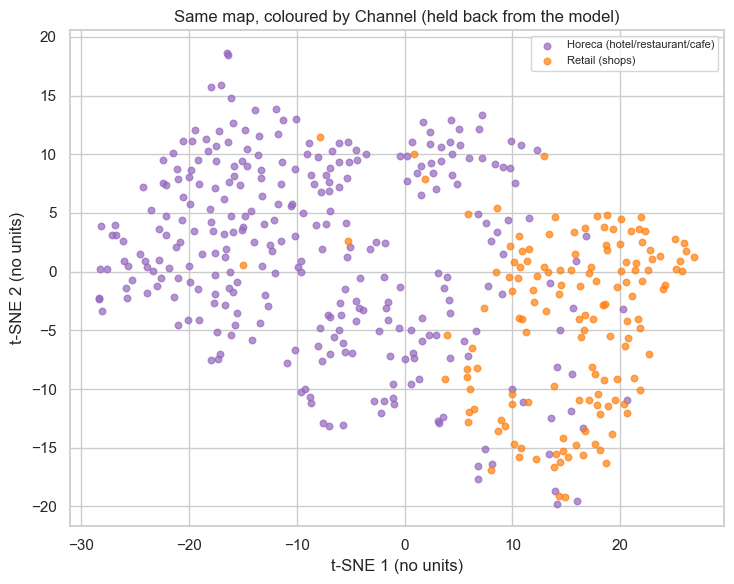

In [7]:
# Readable names and colours for the held-back Channel column (1 = Horeca, 2 = Retail).
channel_names = {1: "Horeca (hotel/restaurant/cafe)", 2: "Retail (shops)"}
channel_palette = {1: "#9467bd", 2: "#ff7f0e"}  # purple, orange

# Draw the SAME t-SNE coordinates, but colour by Channel — a column t-SNE never saw.
plt.figure(figsize=(7.5, 6))
# One scatter call per channel value.
for ch, color in channel_palette.items():
    # A True/False mask selecting customers with this channel.
    m = (wholesale["Channel"] == ch).values
    # Plot those customers at their (unchanged) t-SNE coordinates.
    plt.scatter(tsne_coords[m, 0], tsne_coords[m, 1], s=22, c=color, label=channel_names[ch], alpha=0.7)
# Same unitless axes as before.
plt.xlabel("t-SNE 1 (no units)"); plt.ylabel("t-SNE 2 (no units)")
plt.title("Same map, coloured by Channel (held back from the model)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**What we see.** The map splits cleanly into a **left** region that is almost entirely purple (Horeca) and a **right** region that is mostly orange (Retail), with a soft seam between them. The t-SNE map — built from spending alone — has **rediscovered the Horeca-versus-Retail business distinction on its own.** This is the single most persuasive slide you can show a sceptical room: *"we never told the computer which customers were restaurants and which were shops, and yet look — it separated them anyway, purely from how they spend."* When a held-back fact lines up with your picture, the picture earns trust.


***
## 7.10 Reading t-SNE responsibly — three honest caveats

t-SNE is persuasive, and persuasive tools are dangerous in the wrong hands. A responsible analyst shows the picture *and* tells the room exactly which parts of it to trust. There are **three** things people routinely over-read in a t-SNE plot. Learn them, and say them out loud in the meeting.

**Caveat 1 — the distance *between* blobs is not meaningful.** You cannot say *"the green and red territories are far apart, so those segments are very different, while green and blue are close, so they are similar."* t-SNE only ever tried to preserve **local** neighbourhoods; it made no promise about the gaps *between* groups. Two blobs sitting far apart on the canvas may be no more different than two blobs sitting close.

**Caveat 2 — blob size and density are not meaningful.** A tight little clump is **not** necessarily a set of more-similar customers, and a big sprawling blob is not necessarily more varied. t-SNE stretches sparse regions and compresses dense ones as a side effect of how it works. Do not let anyone in the room say *"this segment is tighter, so it is more coherent."*

**Caveat 3 — different settings produce different pictures.** Change the perplexity, or start the layout from a different random position, and the map rearranges itself. The *groupings* are stable; the *global arrangement* is not.

Caveat 3 is the one people find hardest to believe, so let us **demonstrate** it. Below we run t-SNE **six** times: three perplexities (5, 30, 50) across two random starts (seeds 42 and 7). To make the random start actually bite, we switch to `init="random"` here (recall our main map used the stable `init="pca"`). Watch how the layout dances while the colours stay together.


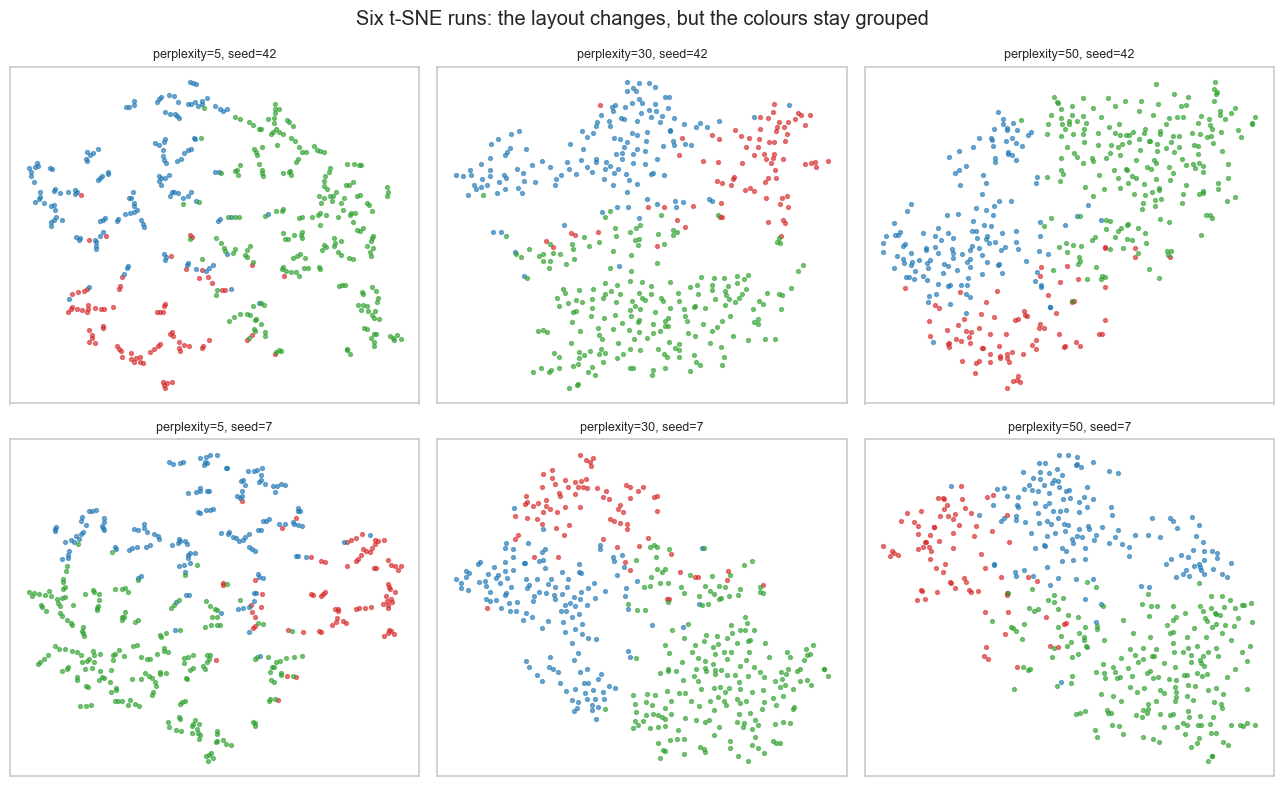

In [8]:
# We will try three perplexity values and two random starts, and lay the six maps out in a grid.
perplexities = [5, 30, 50]
seeds = [42, 7]

# Make a 2-row (one per seed) by 3-column (one per perplexity) grid of plots.
fig, axes = plt.subplots(len(seeds), len(perplexities), figsize=(13, 8))

# Loop over seeds (rows) and perplexities (columns).
for r, seed in enumerate(seeds):
    for c, perp in enumerate(perplexities):
        # Use init="random" here so the random seed genuinely changes the starting layout.
        ts = TSNE(n_components=2, perplexity=perp, init="random", learning_rate="auto", random_state=seed)
        # Fit this version of t-SNE.
        emb = ts.fit_transform(X_scaled.values)
        # Select this panel of the grid.
        ax = axes[r, c]
        # Colour the dots by segment, using our fixed palette.
        for name, color in seg_palette.items():
            m = (wholesale["segment"] == name).values
            ax.scatter(emb[m, 0], emb[m, 1], s=8, c=color, alpha=0.6)
        # Label the panel with its settings; hide the unitless ticks for clarity.
        ax.set_title(f"perplexity={perp}, seed={seed}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

# A shared title and tidy layout.
fig.suptitle("Six t-SNE runs: the layout changes, but the colours stay grouped")
plt.tight_layout(); plt.show()

**What we see.** Three lessons jump out of this grid:

- **At perplexity 5** (left column), the map **shatters** into many small, stringy clumps. With such a local view, t-SNE finds lots of tiny neighbourhoods rather than three big segments. If you trusted this picture naively, you might announce *"there are a dozen customer types!"* — and you would be fooled by the setting, not the data.
- **At perplexity 30 and 50** (middle and right), three big blobs reappear — but their **arrangement on the canvas changes** from panel to panel: which blob is on top, how they are rotated, how far apart they sit. That is Caveat 1 and Caveat 3 in action.
- **Through all six panels, the colours stay together.** Green sits with green, blue with blue, red with red. The *grouping* — the thing t-SNE actually preserves — is robust, even as the *layout* is not.

This is why our main map (§7.8) used `init="pca"`: a fixed, sensible starting point makes the run **reproducible**, so when a colleague re-runs your notebook they get the same picture you presented. The deeper discipline, captured perfectly by the classic interactive article *"How to Use t-SNE Effectively"* (linked in §7.15): **trust which points group together; never read the distances, the gaps, or the blob sizes.**


***
## 7.11 PCA vs t-SNE — two tools, two jobs

We have now built both maps, so let us set them side by side honestly. Neither is "better"; they answer different questions.

| | **PCA** (§7.6) | **t-SNE** (§7.7–7.10) |
|---|---|---|
| Kind of method | Linear (rotate and flatten) | Non-linear (bend and stretch) |
| What it preserves | Global structure, the big directions of spread | Local neighbourhoods (who is near whom) |
| Are distances meaningful? | **Yes** — distances and directions mean something | **No** — between-blob distances and sizes are not meaningful |
| Visual separation of clusters | Often smeared, groups overlap | Usually crisp, groups pop apart |
| Reproducible? | Yes, deterministic | Only if you fix the start (`init`, `random_state`) |
| Speed | Fast | Slower |
| Axes have meaning? | Yes — weighted blends of the original columns | No — just a layout |

**The practical rule.** Reach for **PCA** when you need *meaningful distances* or a quantitative summary — for example, *"how much of the variation do two dimensions capture?"* (we got 71%). Reach for **t-SNE** when your job is to *show clusters to people* — a single, convincing picture for a meeting. This week's job is communication, so t-SNE is our headline tool, with PCA as the honest, distance-preserving counterpart.

**A word on the wider family**, so the names are not a mystery if you meet them later. PCA has older relatives that also try to preserve distances or local structure — **MDS** (multidimensional scaling), **Isomap**, and **LLE** (locally linear embedding). And t-SNE has a popular modern successor, **UMAP**, which tends to be faster and to preserve a little more of the global structure, while sharing t-SNE's "trust the groupings, not the gaps" caveats. We will not use these in this course; we name them only so the landscape is familiar.


***
## 7.12 The Cluster Story Pack — assembling the deliverable

We now have everything the meeting needs. Let us assemble the reusable **Cluster Story Pack**. Its four pieces:

1. **One hero picture** — the t-SNE map, coloured and named, with each segment's size in the legend. We draw the final, slide-ready version below.
2. **A stakeholder narrative** — who each segment is and the one "so what" per segment (we draft this with Anthropic in §7.13, and hand-write the final in §7.14).
3. **An honesty box** — the three caveats from §7.10, plus the standing "describes these customers, not a forecast" line.
4. **A slide-deck outline** — structured headings and which chart goes on each slide (Anthropic drafts this in §7.13).

First, the hero picture — the single image you would project on the wall.


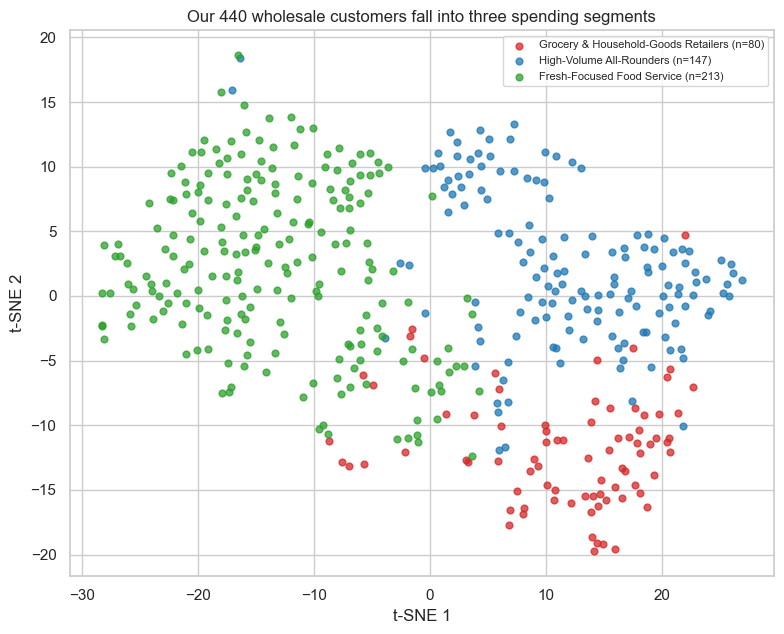

In [9]:
# The single "hero" picture for the slide deck: the t-SNE map with named segments and their sizes.
plt.figure(figsize=(8, 6.5))
# One scatter call per segment.
for name, color in seg_palette.items():
    # A True/False mask selecting this segment's customers.
    m = (wholesale["segment"] == name).values
    # Count this segment's size to show it directly in the legend, so the slide is self-explanatory.
    n = int(m.sum())
    # Plot the segment, putting its size in the legend label.
    plt.scatter(tsne_coords[m, 0], tsne_coords[m, 1], s=24, c=color, label=f"{name} (n={n})", alpha=0.75)
# Plain, headline-style title and unitless axes.
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("Our 440 wholesale customers fall into three spending segments")
plt.legend(fontsize=8, loc="best"); plt.tight_layout(); plt.show()

That single image carries the whole story: three clearly separated, named groups, with their sizes, drawn from spending alone. Now we let Anthropic help us turn the **numbers** behind it into a slide-deck outline and a stakeholder paragraph.


***
## 7.13 Our API calls — Anthropic drafts the slide deck

> **Callback to §1.11, §2.13, §3.12, §4.16, §5.20, §6.16.** Session 01 made plain-text Anthropic calls. Session 03 stepped up to **schema-enforced** structured output using **Anthropic's tool use** with a Pydantic schema (§3.12). Session 06 used a **nested** schema — a playbook containing a list of segments (§6.16). **Same pattern this week**, now producing a *slide-deck outline* that contains a **list of slides**.

> **Why Anthropic only.** This course uses **Anthropic Claude exclusively** — no second provider, no second SDK, no second key. The Messages API plus tool use gives us everything: plain-text generation for language, and schema-enforced output for structured deliverables. (Course **Principle 20**.)

This is also where you build the **Stakeholder Translator Assistant** promised in §7.2 — not as a separate file, but as the *system persona* we give Anthropic in the calls below. Its whole job is to translate analyst-speak (segment statistics, a t-SNE map) into stakeholder-speak (a slide outline and a plain narrative with "so what" actions).

We make **two API calls**, both to Anthropic:

1. **Call 1 — schema-enforced slide-deck outline.** Anthropic turns our computed numbers into a structured outline — a deck title, an ordered **list of slides** (each with a title, a key message, which chart to show, and talking points), and an honesty note — as a JSON object that *conforms to a Pydantic schema we define in Python.*
2. **Call 2 — plain-text stakeholder paragraph.** Anthropic drafts a short narrative a VP could read in the meeting, with a "so what" per segment.

The unbreakable rule is the same as every prior session: **"Python computes, the model interprets."** We pass the model the numbers we calculated — including the t-SNE facts from §7.8 and §7.10 — and it phrases and structures them, but it never invents a figure, and it is told in plain words that the t-SNE distances are not meaningful.

### Step 1 — verify the API key is available


In [10]:
# Import os so we can read environment variables.
import os

# Read the Anthropic API key from the environment.
anth_key = os.environ.get("ANTHROPIC_API_KEY")

# If the key is missing, halt the notebook with a clear, actionable message (do not silently continue).
if not anth_key:
    raise SystemExit(
        "ANTHROPIC_API_KEY is not set in your environment.\n"
        "Follow Step 4 of the repository README, close VS Code, reopen, and re-run this cell."
    )

# Confirm the key is set without printing its value.
print(f"ANTHROPIC_API_KEY is set. Key length: {len(anth_key)} characters.")

ANTHROPIC_API_KEY is set. Key length: 108 characters.


### Step 2 — create the Anthropic client


In [11]:
# Import the official Anthropic Python SDK.
import anthropic

# Create the Anthropic client; it picks up ANTHROPIC_API_KEY from the environment automatically.
client = anthropic.Anthropic()

# Print a confirmation that the client object was created successfully.
print("Anthropic client ready.")

Anthropic client ready.


### Step 3 — define a Pydantic schema for the slide deck

> **Callback to §3.12 and §6.16.** Pydantic gives us the JSON Schema for free: we write ordinary Python classes, and `.model_json_schema()` returns the schema dict Anthropic's tool use expects. As in Session 06 we use a **nested** schema, because a deck naturally contains a *list of slides*.

- **`Slide`** describes **one** slide: a `title`, a `key_message`, which `chart_to_show`, and a few `talking_points`.
- **`StoryDeckOutline`** is the whole deliverable: a `deck_title`, a `slides` list (one `Slide` each), and an `honesty_note`.


In [12]:
# Import Pydantic's BaseModel and Field helpers (installed in the `ailab` venv as an Anthropic SDK dependency).
from pydantic import BaseModel, Field

# typing.List lets us declare "a list of Slide objects" in the schema.
from typing import List

# Describe ONE slide of the deck.
class Slide(BaseModel):
    title: str = Field(
        description="A short, plain-English slide title a non-technical executive would understand."
    )
    key_message: str = Field(
        description="The single most important sentence this slide should land, grounded ONLY in the numbers provided."
    )
    chart_to_show: str = Field(
        description="Which chart from the notebook to put on this slide (for example the t-SNE segment map, the "
                    "Channel-overlay map, or the per-segment spending table), and one phrase on why it supports the message."
    )
    talking_points: List[str] = Field(
        description="Two to four short bullet points the presenter can say aloud, each grounded in the numbers provided."
    )

# Describe the WHOLE deck outline: a title, an ordered list of slides, and an honesty note.
class StoryDeckOutline(BaseModel):
    deck_title: str = Field(
        description="A short title for the whole deck."
    )
    slides: List[Slide] = Field(
        description="Four to six slides in presentation order: an opening, one slide per key idea, and a closing 'so what' slide."
    )
    honesty_note: str = Field(
        description="Two to three caveats for the speaker: that the segmentation DESCRIBES these 440 customers and is not a "
                    "forecast; that a t-SNE picture shows which customers group together but its distances and blob sizes are "
                    "NOT meaningful; and that the segment boundaries are soft."
    )

# Print confirmation that the schema is defined.
print("Pydantic schema StoryDeckOutline (with nested Slide) defined.")

Pydantic schema StoryDeckOutline (with nested Slide) defined.


### Step 4 — assemble the numbers and call Anthropic with a forced tool

The mechanics match §3.12, §4.16, §5.20, and §6.16 exactly. First a **safety re-fit** cell rebuilds every number this section needs (so it runs correctly even after a kernel restart) and assembles the per-segment figures **and the visualisation facts** into a plain-text block — *the only numbers the model is allowed to use.* Then we build a tool from our Pydantic schema and force the model to call it (`tool_choice`), so the reply must be a schema-valid deck outline.


In [13]:
# Safety re-fit — rebuild every number this section needs, regardless of run order.
# (Pipeline and labels from §7.3; profiles are the Session 06 numbers; t-SNE and PCA facts from §7.6 and §7.8.)

# Per-cluster mean spend in original monetary units, the sizes, and the total revenue per segment.
profile = wholesale.groupby("cluster")[spend_cols].mean().round(0).astype(int)
sizes = wholesale["cluster"].value_counts().sort_index()
revenue = wholesale.groupby("cluster")[spend_cols].sum().sum(axis=1)
total_rev = revenue.sum()

# The Channel mix per cluster (1 = Horeca, 2 = Retail) — our held-back validation.
channel_tab = pd.crosstab(wholesale["cluster"], wholesale["Channel"])

# Build the numbers summary the model is allowed to see (Python computes, the model interprets).
lines = []
# A framing line stating what the segmentation is and is not.
lines.append(
    f"We segmented n = {len(wholesale)} wholesale customers into 3 groups using annual spend across six product "
    f"categories (log-transformed, then standardised), with k-means. This DESCRIBES these {len(wholesale)} customers; "
    f"it is not a forecast about new customers."
)
# The visualisation facts, in words the model can quote responsibly.
lines.append(
    f"To communicate the segments we built a 2D t-SNE map (perplexity 30). On that map, {purity*100:.1f}% of each "
    f"customer's 10 nearest neighbours share its segment, so the map keeps like with like. A PCA projection keeps "
    f"{evr[:2].sum()*100:.1f}% of the spread in two dimensions. IMPORTANT: in a t-SNE picture the distances between "
    f"groups and the sizes of the blobs are NOT meaningful, and different settings redraw the layout. Also, the held-back "
    f"Channel column lines up with the map: the Fresh-Focused segment is almost entirely Horeca."
)
# One line per segment with its size, revenue share, basket, and Channel mix.
for cid in [0, 1, 2]:
    nm = segment_names[cid]
    n = int(sizes[cid])
    rev = int(revenue[cid])
    means = ", ".join(f"{c} {profile.loc[cid, c]:,}" for c in spend_cols)
    hor = int(channel_tab.loc[cid, 1]); ret = int(channel_tab.loc[cid, 2])
    lines.append(
        f"\nSegment {cid} '{nm}': {n} customers ({n/len(wholesale)*100:.1f}% of base); total annual spend {rev:,} m.u. "
        f"({rev/total_rev*100:.1f}% of all spend). Average spend per customer: {means}. Channel mix: {hor} Horeca, {ret} Retail."
    )

# Join into one block of text and show it.
segment_numbers = "\n".join(lines)
print(segment_numbers)

We segmented n = 440 wholesale customers into 3 groups using annual spend across six product categories (log-transformed, then standardised), with k-means. This DESCRIBES these 440 customers; it is not a forecast about new customers.
To communicate the segments we built a 2D t-SNE map (perplexity 30). On that map, 88.5% of each customer's 10 nearest neighbours share its segment, so the map keeps like with like. A PCA projection keeps 71.3% of the spread in two dimensions. IMPORTANT: in a t-SNE picture the distances between groups and the sizes of the blobs are NOT meaningful, and different settings redraw the layout. Also, the held-back Channel column lines up with the map: the Fresh-Focused segment is almost entirely Horeca.

Segment 0 'Grocery & Household-Goods Retailers': 80 customers (18.2% of base); total annual spend 2,363,842 m.u. (16.2% of all spend). Average spend per customer: Fresh 2,899, Milk 7,136, Grocery 12,570, Frozen 607, Detergents_Paper 5,554, Delicassen 783. Channel

In [14]:
# Build the Anthropic tool spec from our Pydantic schema.
# model_json_schema() returns a JSON Schema dict — exactly what Anthropic's `input_schema` expects.
deck_tool = {
    "name": "submit_story_deck_outline",
    "description": "Submit a stakeholder slide-deck outline for the segmentation. You MUST call this tool with every required field filled in.",
    "input_schema": StoryDeckOutline.model_json_schema(),
}

# Call Claude. `tool_choice` forces the model to call this specific tool — it cannot reply with free text.
deck_response = client.messages.create(
    model="claude-haiku-4-5",                                       # same Haiku model as §§1.11–6.16
    max_tokens=2000,                                                # room for several slides plus notes
    system=(                                                        # the Stakeholder Translator persona
        "You are a Stakeholder Translator Assistant. You turn a computed customer segmentation and its "
        "visualisations into a short, non-technical slide-deck outline for a VP of Sales. You enforce four "
        "disciplines: (1) use ONLY the numbers given to you, never invent figures or traits; (2) keep every slide "
        "in plain business language with a clear 'so what'; (3) frame the segmentation as a description of THESE "
        "customers, not a forecast about new ones; (4) when a slide uses the t-SNE map, remind the presenter that it "
        "shows which customers group together but that its distances and blob sizes are not meaningful."
    ),
    tools=[deck_tool],                                              # the only tool the model may call
    tool_choice={"type": "tool", "name": "submit_story_deck_outline"},  # force this specific tool
    messages=[
        {
            "role": "user",
            "content": (
                "Here is the segmentation and its visualisations:\n\n"
                + segment_numbers
                + "\n\nProduce the slide-deck outline. Four to six slides in presentation order, plain language, "
                + "and use only the numbers above."
            ),
        }
    ],
)

# Scan the response for the tool_use block. Because tool_choice forced our tool, exactly one exists.
deck_dict = None
for block in deck_response.content:
    if block.type == "tool_use":
        deck_dict = block.input    # this dict already conforms to our schema — Anthropic enforced it
        break

# Wrap the dict back into our Pydantic class for type-safe access.
deck = StoryDeckOutline(**deck_dict)

# Print the deck outline slide by slide.
print(f"DECK: {deck.deck_title}\n")
for i, s in enumerate(deck.slides, start=1):
    print(f"Slide {i}: {s.title}")
    print(f"   Key message: {s.key_message}")
    print(f"   Chart:       {s.chart_to_show}")
    for tp in s.talking_points:
        print(f"     - {tp}")
    print()

# Print the honesty note.
print("Honesty note:", deck.honesty_note)

DECK: Three Customer Segments for Sales Strategy

Slide 1: We've Grouped Your 440 Customers into Three Segments
   Key message: Our analysis groups your 440 wholesale customers into three distinct buying patterns based on their annual spending across fresh, dairy, grocery, frozen, household, and delicatessen categories.
   Chart:       t-SNE segment map showing the three customer clusters, with a note that distances and blob sizes are not meaningful but the map shows which customers group together naturally.
     - Segment 0 'Grocery & Household-Goods Retailers': 80 customers (18% of your base), mostly Retail-focused.
     - Segment 1 'High-Volume All-Rounders': 147 customers (33% of your base), balanced mix of both channels.
     - Segment 2 'Fresh-Focused Food Service': 213 customers (48% of your base), almost entirely Horeca (food service).

Slide 2: Segment 1 Drives Over Half Your Revenue
   Key message: The 147 'High-Volume All-Rounders' generate 53% of your total annual spend (£7

**What we see.** Anthropic returns a tool call whose `input` is a JSON object matching our nested schema exactly: a deck title, an ordered list of slides (each with a message, a chart, and talking points), and an honesty note. Because `tool_choice` forced the tool, no validation step is needed — the model *cannot* return something off-schema. Same generation-time guarantee as §3.12, §4.16, §5.20, and §6.16, now producing a list of slides.

### Call 2 — Anthropic drafts the stakeholder paragraph

Now we hand the same computed numbers to Anthropic and ask for a short plain-text paragraph a VP could read in the meeting, with a "so what" per segment. Same *"Python computes, the model interprets"* rule.


In [15]:
# Call Anthropic for a short plain-text stakeholder narrative with "so what" actions.
narrative_response = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=500,
    system=(
        "You are a Stakeholder Translator Assistant. You turn segment statistics into one short, plain-English "
        "paragraph for a VP of Sales: lead with how many segments there are and where the revenue concentrates, "
        "name each segment by what it buys, and give each a one-phrase 'so what' action. Close with a one-sentence "
        "honesty caveat. Use ONLY the numbers given to you; never invent numbers."
    ),
    messages=[
        {
            "role": "user",
            "content": (
                "Here is the segmentation:\n\n"
                + segment_numbers
                + "\n\nWrite ONE short paragraph (4 to 6 sentences) a VP of Sales could read in a meeting, with a "
                + "'so what' action per segment and an honest closing caveat."
            ),
        }
    ],
)

# Print Anthropic's paragraph.
print(narrative_response.content[0].text)

You have 440 wholesale customers split into three segments, with revenue heavily concentrated in the High-Volume All-Rounders (53% of spend from 33% of customers). Your Grocery & Household-Goods Retailers (80 customers, 16% of revenue) buy balanced across milk, grocery, and detergents—*focus here on category bundling and cross-sell*; your High-Volume All-Rounders (147 customers, 53% of revenue) dominate fresh and frozen spend across all categories—*protect these accounts and expand their frozen penetration*; and your Fresh-Focused Food Service (213 customers, 31% of revenue) are almost entirely Horeca venues buying fresh and frozen only—*serve them with streamlined fresh logistics and skip the dry goods*. This segmentation describes your current 440 customers well (88.5% of neighbors share segment membership), but it doesn't predict how new customers will sort into these groups.


**What we see.** A short, plain-English paragraph that leads with the three segments and where the money is, names each by its basket, attaches a "so what" to each, and closes with an honest caveat. The model invented **no numbers** — it used only the set we computed and handed it.

> **Mini-recap of §7.13.** Two API calls, one provider. Anthropic tool use with a (nested) Pydantic-derived schema **guarantees** the structured deck outline at generation time; plain-text Anthropic drafts the stakeholder paragraph from computed numbers. Same *"Python computes, the model interprets"* discipline as Sessions 01–06; same single-provider architecture as §3.12, §4.16, §5.20, and §6.16. (Principle 20.)


***
## 7.14 The cluster story pack — fully worked

It is Friday afternoon. Here is the complete **Cluster Story Pack** you would carry into Tuesday's meeting. Every number is grounded in a cell you can re-run.

---

### 1. The hero picture

The t-SNE map from §7.12: all **440 customers** as dots on one canvas, coloured into three named segments with their sizes. About **88%** of each customer's nearest neighbours on the map share its segment, and the held-back `Channel` column (§7.9) splits left/right across the same map — strong, independent signs the groups are real.

### 2. Stakeholder narrative

Our 440 wholesale customers fall into **three spending segments**, and they are easy to tell apart once you see them on the map.

- **Fresh-Focused Food Service** — **213 customers (48% of the base), about 31% of revenue.** Kitchens: restaurants, cafés, hotels (210 of 213 are Horeca). They live on **`Fresh`** (avg ~11,939 m.u.) with some `Frozen`, and barely touch packaged grocery or detergents (avg `Detergents_Paper` ~424 vs the ~2,881 base average). **So what:** win them on **supply reliability** — guaranteed fresh deliveries, not catalogue breadth.
- **High-Volume All-Rounders** — **147 customers (33%), about 53% of revenue.** The biggest accounts, above average on every category. A third of customers, **over half of all spend.** **So what:** give them **named account managers and volume deals**; losing one costs far more than losing a small account.
- **Grocery & Household-Goods Retailers** — **80 customers (18%), about 16% of revenue.** Shops: high on **`Grocery`** (~12,570) and **`Detergents_Paper`** (~5,554), low on `Fresh` (~2,899). **So what:** serve them **efficiently with standing orders** on the shelf-stable and household range.

### 3. Honesty box

- This **describes these 440 customers** as they spent this year; it is **not a forecast** about new customers.
- The map is a **t-SNE picture**: trust *which customers group together*, but do **not** read the distances between blobs or the sizes of blobs as meaningful, and remember different settings redraw the layout.
- k-means drew **hard lines through a continuum** — customers near a seam could reasonably belong to either neighbouring segment.

### 4. Slide-deck outline

Use the Anthropic-drafted outline printed in §7.13 as your starting skeleton: an opening slide, one slide per segment (each pairing the hero picture or the spending table with a "so what"), the `Channel` validation slide, and a closing honesty slide. Drop your charts into the named slots and you have a deck.

---

This pack is **reusable**: next time you segment any customer base, the same four-piece structure — hero picture, narrative, honesty box, deck outline — carries the story. That is the whole point of the course in one deliverable: **Python found the segments and the figures; t-SNE made them visible; the model helped name and narrate them; every claim traces back to a cell you can re-run.**


***
## 7.15 References — what to study to deepen this session

A short, focused list. If you watch only one video, make it the StatQuest *t-SNE, Clearly Explained* — it animates the neighbourhood idea of §7.7 beautifully. If you read only one article, make it the Distill piece on using t-SNE effectively — it *is* §7.10, with interactive sliders.

### StatQuest videos (YouTube)

| Video | What it clarifies |
|---|---|
| [StatQuest: t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM) | Josh Starmer animates how t-SNE moves points so that neighbours stay neighbours — exactly the intuition of §7.7, including what perplexity does. |
| [StatQuest: Principal Component Analysis (PCA), Step-by-Step](https://www.youtube.com/watch?v=FgakZw6K1QQ) | A gentle, visual walk through how PCA finds the directions of greatest spread — the foundation under §7.6, and a useful contrast to t-SNE. |

### Essential reading on reading t-SNE honestly

- [How to Use t-SNE Effectively (Distill, Wattenberg, Viégas & Johnson)](https://distill.pub/2016/misread-tsne/) — an interactive article whose whole message is §7.10: change the perplexity and the random seed with live sliders and *watch* the picture rearrange, learning by hand why distances and blob sizes are not meaningful. The single best resource for reading these plots responsibly.
- [Visualizing Data using t-SNE (van der Maaten & Hinton, 2008)](https://www.jmlr.org/papers/v9/vandermaaten08a.html) — the original paper that introduced t-SNE, for the genuinely curious. Skim the figures even if the mathematics is for later.

### Documentation

- [scikit-learn `TSNE`](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — the class we fit in §§7.8–7.10, including the `perplexity`, `init`, and `random_state` arguments we discussed.
- [scikit-learn `PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — the class behind §7.6 and its `explained_variance_ratio_`.
- [scikit-learn: Manifold learning](https://scikit-learn.org/stable/modules/manifold.html) — the wider guide to t-SNE and its cousins (Isomap, LLE, MDS) named in §7.11, with honest notes on their quirks.
- [Anthropic tool use](https://docs.anthropic.com/en/docs/build-with-claude/tool-use) — the schema-enforced output mechanism behind §7.13's deck outline.

### Khan Academy

- [Statistics & Probability hub](https://www.khanacademy.org/math/statistics-probability) — the full track; the data-visualization and interpretation units are what make a picture *credible* to stakeholders.
- [Box plot review](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/box-whisker-plots/a/box-plot-review) — a robust way to compare segments side by side when a table is needed alongside the map.

### Dataset

- [Wholesale customers dataset, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/292/wholesale+customers) — the same 440 clients as Session 06, licensed **CC BY 4.0**. We reuse it so the segmentation and its visualisation are one continuous story.


***
## 7.16 Recap, and a look ahead to Session 08

**What you did this week.** You took a segmentation that lived in six invisible dimensions and made it *visible and sellable*:

- you saw **why two-axis plots fail** (§7.4) and what **dimension reduction** is — a faithful two-dimensional shadow (§7.5);
- you built a **PCA** map (linear, distances meaningful, but groups smeared — §7.6) and a **t-SNE** map (non-linear, groups crisp, distances *not* meaningful — §§7.7–7.8);
- you ran an **external-validation** check, watching the held-back `Channel` split the map left/right (§7.9);
- you learned to **read t-SNE responsibly** — trust the groupings, never the gaps, the sizes, or a single setting (§7.10);
- you compared **PCA and t-SNE** as two tools for two jobs (§7.11);
- and you assembled a reusable **Cluster Story Pack** with an Anthropic-drafted slide outline (§§7.12–7.14).

**Where we go next — Session 08.** We have spent two weeks in the world of *unsupervised* learning: in Session 06 we put the answer key away and discovered segments; this week we drew them. **Next week we pick the answer key back up.** Session 08 returns to *supervised* learning — predicting a known target — but with a model the business actually loves: the **decision tree**, which makes its predictions as a chain of plain *if-then* rules a manager can read and act on. We will grow trees for both a number (wine quality) and a yes/no (churn), learn to keep them from over-fitting, and turn a trained tree into a simple decision policy. And we will finally open the box we left closed in §7.7: the **information theory** — entropy and the idea of measuring "surprise" — that decision trees use to choose their splits, and that quietly powers t-SNE too. See you there.


<hr>

![](../_img/DK_Logo_White_150.png)

DataKolektiv, 2026.

[hello@datakolektiv.com](mailto:hello@datakolektiv.com)


<font size=1>License: [GPLv3](../LICENSE). This Notebook is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version. This Notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.</font>
